In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.metrics import mean_absolute_error

In [49]:
df = pd.read_csv("clean_normal_cells.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.rename(columns={
    "(HU) Cell DL Average Throughput (Mbps)": "DL_Throughput",
    "(HU) DL Traffic Volume (GBytes)": "DL_Traffic",
    "(HU) Average UE Number": "Avg_UE_Number",
    "L.Traffic.ActiveUser.Avg": "Active_Users"
})

In [118]:
cell_counts = (
    df.groupby("Cell Name")
      .size()
      .sort_values(ascending=False)
)

cell_name = cell_counts.index[5]

cell_df = (
    df[df["Cell Name"] == cell_name]
      .sort_values("Date")
      .set_index("Date")
)

print(cell_name)
print(len(cell_df))

LCAIN10021-1
30


In [119]:
cell_df = cell_df[
    [
        "DL_Throughput",
        "DL_Traffic",
        "Avg_UE_Number",
        "Active_Users"
    ]
]

print(cell_df.head())

            DL_Throughput  DL_Traffic  Avg_UE_Number  Active_Users
Date                                                              
2026-04-19        10.9566     11.9749         4.1906        0.4524
2026-04-20        12.9103     14.7249         4.3589        0.4678
2026-04-21        16.4401     24.0671         4.1013        0.5233
2026-04-22        11.0768     12.4642         4.1264        0.4888
2026-04-23         8.0313      8.1437         4.0254        0.4498


In [156]:
features = pd.DataFrame(index=cell_df.index)

# --- Target ---
features["y"] = cell_df["DL_Throughput"]

# --- Telecom KPIs ---
features["DL_Traffic"] = cell_df["DL_Traffic"]
features["Avg_UE_Number"] = cell_df["Avg_UE_Number"]
features["Active_Users"] = cell_df["Active_Users"]

# --- Lag features ---
features["lag_1"] = features["y"].shift(1)
features["lag_2"] = features["y"].shift(2)
features["lag_3"] = features["y"].shift(3)
features["lag_4"] = features["y"].shift(4)
features["lag_5"] = features["y"].shift(5)
features["lag_6"] = features["y"].shift(6)
features["lag_7"] = features["y"].shift(7)

# --- Rolling stats over the prior week (shifted to avoid leakage) ---
features["rolling_mean_3"] = features["y"].shift(1).rolling(3).mean()
features["rolling_mean_7"] = features["y"].shift(1).rolling(7).mean()
features["week_mean"] = features["y"].shift(1).rolling(7).mean()
features["week_std"]  = features["y"].shift(1).rolling(7).std()
features["week_max"]  = features["y"].shift(1).rolling(7).max()
features["week_min"]  = features["y"].shift(1).rolling(7).min()

# --- Shape of the previous week: normalized lags ---
for k in range(1, 8):
    features[f"lag{k}_norm"] = features[f"lag_{k}"] / features["week_mean"]

# --- Where same-day-last-week sits in last week's range ---
week_range = features["week_max"] - features["week_min"]
features["lag7_position"] = (features["lag_7"] - features["week_min"]) / week_range.replace(0, pd.NA)

# --- Ratios / trend descriptors ---
features["lag1_to_lag7_ratio"] = features["lag_1"] / features["lag_7"]
features["weekly_slope"] = features["lag_1"] - features["lag_7"]

# Day of week
features["day_of_week"] = features.index.dayofweek

# Remove rows containing NaN
features = features.dropna()

print(features.shape)
features.head()

(23, 28)


,y,DL_Traffic,Avg_UE_Number,Active_Users,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag2_norm,lag3_norm,lag4_norm,lag5_norm,lag6_norm,lag7_norm,lag7_position,lag1_to_lag7_ratio,weekly_slope,day_of_week
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-26,16.2286,23.2890,4.8811,0.5611,13.0226,10.6657,8.0313,11.0768,16.4401,12.9103,...,0.898398,0.676496,0.933026,1.384789,1.087466,0.922901,0.347886,1.188562,2.0660,6
2026-04-27,14.5794,19.6045,4.2469,0.5334,16.2286,13.0226,10.6657,8.0313,11.0768,16.4401,...,1.031488,0.844804,0.636140,0.877366,1.302180,1.022593,0.580225,1.257027,3.3183,0
2026-04-28,11.8576,14.0093,4.4535,0.4729,14.5794,16.2286,13.0226,10.6657,8.0313,11.0768,...,1.261601,1.012368,0.829144,0.624348,0.861103,1.278043,1.000000,0.886819,-1.8607,1
2026-04-29,20.1911,21.3021,3.5243,0.3430,11.8576,14.5794,16.2286,13.0226,10.6657,8.0313,...,1.194166,1.329248,1.066652,0.873603,0.657826,0.907276,0.371525,1.070490,0.7808,2
2026-04-30,16.3710,13.6682,3.5522,0.3155,20.1911,11.8576,14.5794,16.2286,13.0226,10.6657,...,0.877632,1.079084,1.201149,0.963859,0.789414,0.594431,0.000000,2.514051,12.1598,3


In [157]:
split = len(features) - 7

train = features.iloc[:split]
test = features.iloc[split:]

X_train = train.drop(columns="y")
y_train = train["y"]

X_test = test.drop(columns="y")
y_test = test["y"]

print(len(X_train))
print(len(X_test))

16
7


In [158]:
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [161]:
forecast = model.predict(X_test)

print(forecast)

[13.042627 14.753994 15.593833 15.380097 14.38125  15.695627 13.742092]


In [162]:
mae_xgb = mean_absolute_error(y_test, forecast)

print("MAE =", round(mae_xgb,3))

MAE = 1.474


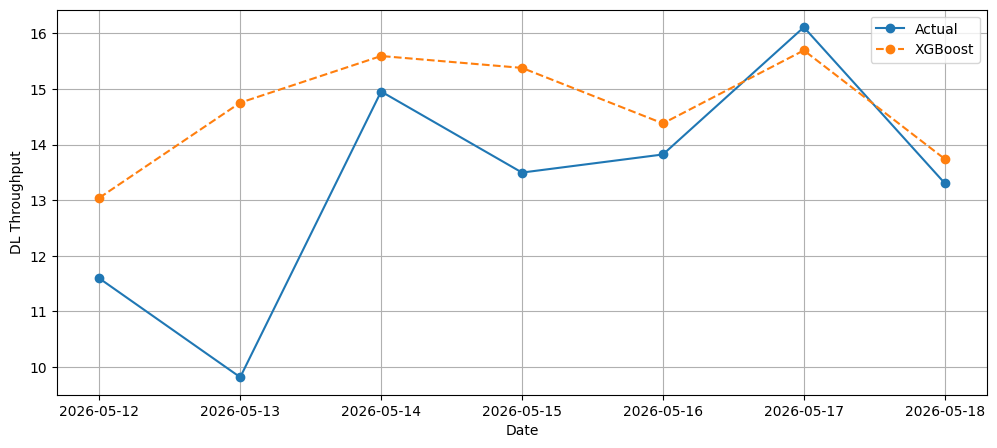

In [163]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test,
         marker='o',
         label='Actual')

plt.plot(y_test.index, forecast,
         marker='o',
         linestyle='--',
         label='XGBoost')

plt.xlabel("Date")
plt.ylabel("DL Throughput")
plt.legend()
plt.grid()

plt.show()

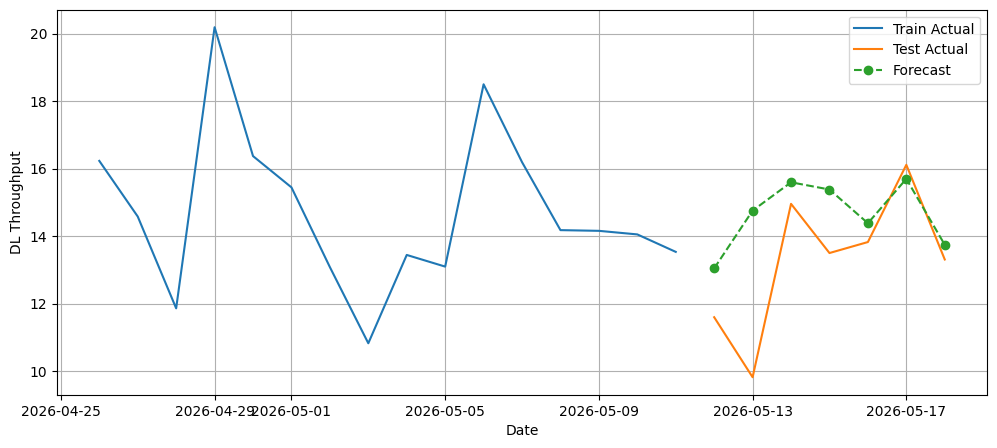

In [164]:
plt.figure(figsize=(12,5))

# Train actual
plt.plot(y_train.index, y_train, label='Train Actual')

# Test actual
plt.plot(y_test.index, y_test, label='Test Actual')

# Forecast
plt.plot(y_test.index, forecast,
         linestyle='--',
         marker='o',
         label='Forecast')

plt.xlabel("Date")
plt.ylabel("DL Throughput")
plt.legend()
plt.grid()
plt.show()

In [166]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string(index=False))

           feature  importance
         week_mean    0.208761
             lag_1    0.080693
     lag7_position    0.080005
             lag_4    0.074785
          week_min    0.069571
lag1_to_lag7_ratio    0.052063
      Active_Users    0.048521
        DL_Traffic    0.044024
         lag3_norm    0.043691
          week_std    0.042996
             lag_7    0.040980
    rolling_mean_7    0.039850
             lag_2    0.025868
         lag1_norm    0.024333
             lag_3    0.023896
       day_of_week    0.020661
         lag5_norm    0.020287
     Avg_UE_Number    0.018456
      weekly_slope    0.011514
          week_max    0.009138
             lag_6    0.008619
         lag2_norm    0.006509
             lag_5    0.003354
         lag6_norm    0.001248
         lag7_norm    0.000175
    rolling_mean_3    0.000000
         lag4_norm    0.000000


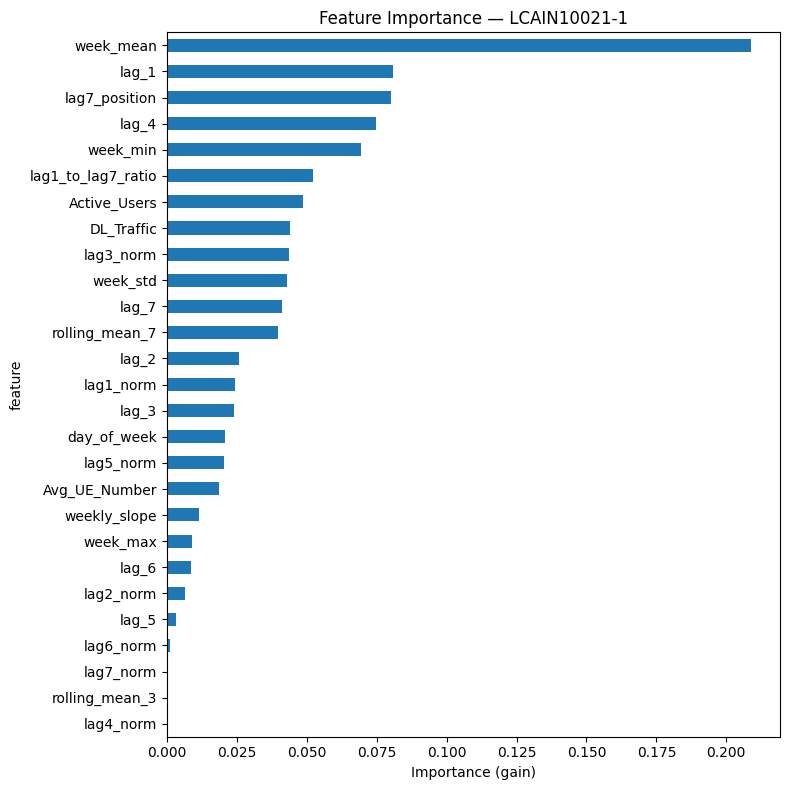

In [165]:
import matplotlib.pyplot as plt

importance_df.plot(
    kind="barh", x="feature", y="importance",
    figsize=(8, 8), legend=False
)
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel("Importance (gain)")
plt.title(f"Feature Importance — {cell_name}")
plt.tight_layout()
plt.show()